# 03 - Feature Engineering

This notebook builds on the cleaned dataset to:

1. Handle outliers and derive `age` / `age_group`
2. Engineer aggregate, share-based, campaign, and tenure features
3. Explore the newly engineered features (post-engineering EDA)
4. Drop redundant / raw columns that are now represented by the new features
5. Inspect the correlation matrix of the final feature set

The result is persisted for the preprocessing pipeline notebook.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
df = pd.read_csv("../data/processed/01_cleaned.csv")
df.shape

(2216, 26)

## Handling Outliers

In [3]:
data_collection_year = 2015
df["age"] = data_collection_year - df["Year_Birth"]

age_outliers = df[df["age"] > 90]
income_outliers = df[df["Income"] >= 120000]

print("Age outliers (> 90):", len(age_outliers))
print("Income outliers (>= 120k):", len(income_outliers))

df = df[(df["age"] <= 90) & (df["Income"] < 120000)].copy()
print("Shape after removing outliers:", df.shape)

labels = ["19-29", "30-39", "40-50", "50-69", "70+"]
df["age_group"] = pd.cut(df["age"], bins=[18, 30, 40, 50, 70, 90], labels=labels)

Age outliers (> 90): 3
Income outliers (>= 120k): 8
Shape after removing outliers: (2205, 27)


## Feature Engineering

In [4]:
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts",
              "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

campaign_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
                  "AcceptedCmp4", "AcceptedCmp5", "Response"]

purchases_cols = ["NumDealsPurchases", "NumWebPurchases",
                   "NumCatalogPurchases", "NumStorePurchases"]

#### Aggregate Features

In [5]:
df["total_children"] = df["Teenhome"] + df["Kidhome"]
df["total_spending"] = df[spend_cols].sum(axis=1)
df["total_purchases"] = df[purchases_cols].sum(axis=1)

In [6]:
mapping = {
    "MntMeatProducts": "meat_share",
    "MntFruits": "fruit_share",
    "MntFishProducts": "fish_share",
    "MntSweetProducts": "sweet_share",
    "MntGoldProds": "gold_share",
}

for col, share_col in mapping.items():
    df[share_col] = df[col].div(df["total_spending"], axis=0).fillna(0)

In [7]:
mapping_purchases = {
    "NumDealsPurchases": "deals_share",
    "NumWebPurchases": "web_share",
    "NumCatalogPurchases": "catalog_share",
    "NumStorePurchases": "store_share",
}

for col, share_col in mapping_purchases.items():
    df[share_col] = df[col].div(df["total_purchases"], axis=0).fillna(0)

#### Campaign Features

In [8]:
df["Total_Accepted_Cmp"] = df[campaign_cols].sum(axis=1)
df["Accepted_Any_Campaign"] = (df["Total_Accepted_Cmp"] > 0).astype(int)

#### Customer Tenure Feature

In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Customer_Days"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days

## Distribution of the New Features

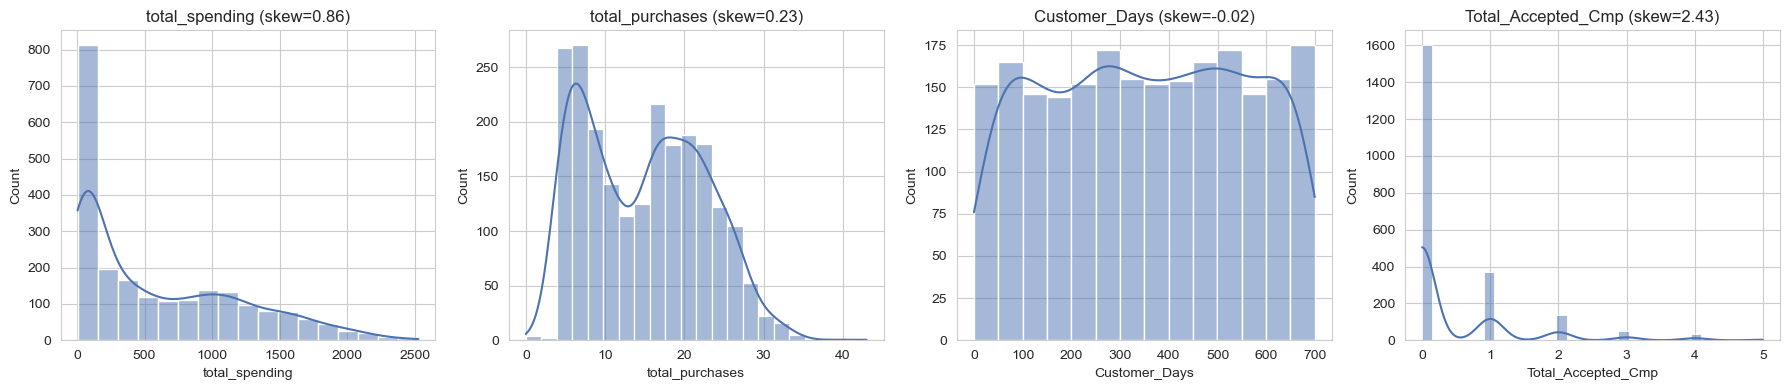

In [10]:
new_features = ["total_spending", "total_purchases", "Customer_Days", "Total_Accepted_Cmp"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(new_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"{col} (skew={df[col].skew():.2f})")
plt.tight_layout()
plt.show()

## Feature Insights (Post-Engineering EDA)

With the new features in place, this section explores how they relate to demographics and behavior:

- Average spending, number of children, and campaign acceptance rate by education level
- Average spending by age group and marital status
- Campaign responders vs non-responders
- Average basket share per product category and per purchase channel
- Income vs total spending, colored by number of children

C:\Users\Windows\AppData\Local\Temp\ipykernel_22468\1947883697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y="Education", x="total_spending", order=edu_order, ax=axes[0], palette="mako", errorbar=None)
C:\Users\Windows\AppData\Local\Temp\ipykernel_22468\1947883697.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y="Education", x="total_children", order=edu_order, ax=axes[1], palette="flare", errorbar=None)
C:\Users\Windows\AppData\Local\Temp\ipykernel_22468\1947883697.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns

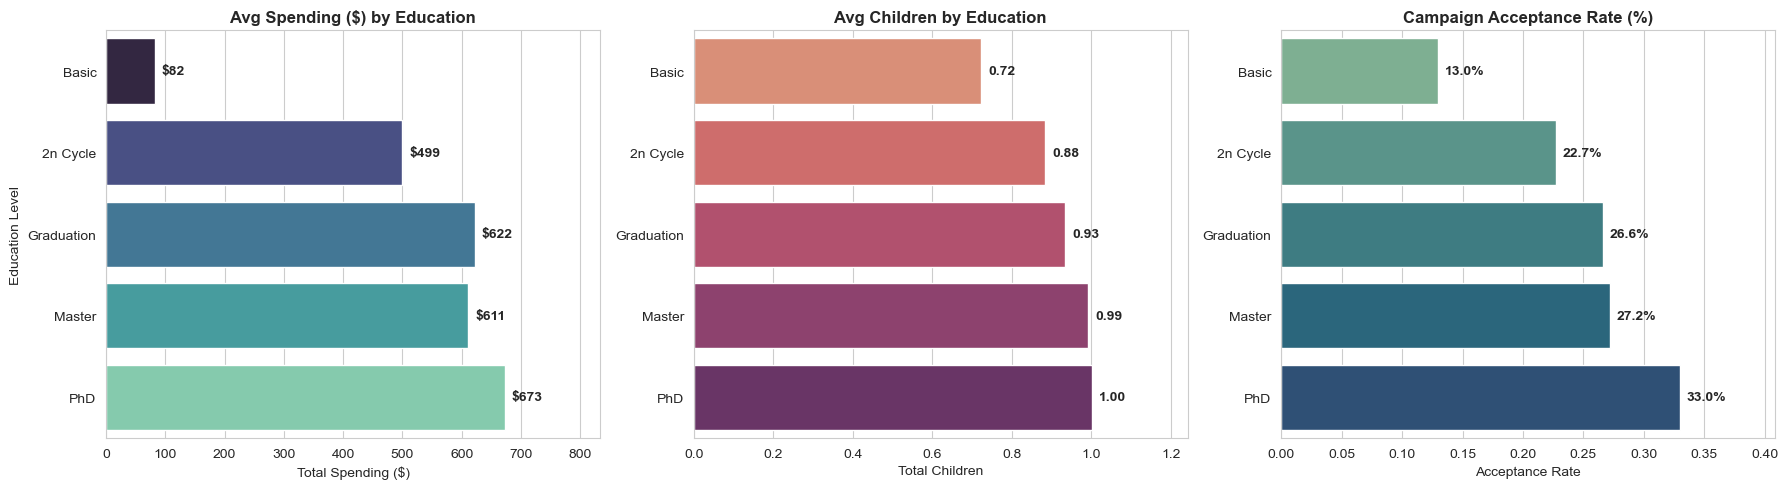

In [11]:
edu_order = ["Basic", "2n Cycle", "Graduation", "Master", "PhD"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, y="Education", x="total_spending", order=edu_order, ax=axes[0], palette="mako", errorbar=None)
axes[0].set_title("Avg Spending ($) by Education", fontweight="bold")
axes[0].set_xlabel("Total Spending ($)")
axes[0].set_ylabel("Education Level")
for p in axes[0].patches:
    w = p.get_width()
    axes[0].annotate(f"${w:,.0f}", (w, p.get_y() + p.get_height() / 2.), ha="left", va="center", xytext=(5, 0), textcoords="offset points", fontweight="bold")

sns.barplot(data=df, y="Education", x="total_children", order=edu_order, ax=axes[1], palette="flare", errorbar=None)
axes[1].set_title("Avg Children by Education", fontweight="bold")
axes[1].set_xlabel("Total Children")
axes[1].set_ylabel("")
for p in axes[1].patches:
    w = p.get_width()
    axes[1].annotate(f"{w:.2f}", (w, p.get_y() + p.get_height() / 2.), ha="left", va="center", xytext=(5, 0), textcoords="offset points", fontweight="bold")

sns.barplot(data=df, y="Education", x="Accepted_Any_Campaign", order=edu_order, ax=axes[2], palette="crest", errorbar=None)
axes[2].set_title("Campaign Acceptance Rate (%)", fontweight="bold")
axes[2].set_xlabel("Acceptance Rate")
axes[2].set_ylabel("")
for p in axes[2].patches:
    w = p.get_width()
    axes[2].annotate(f"{w*100:.1f}%", (w, p.get_y() + p.get_height() / 2.), ha="left", va="center", xytext=(5, 0), textcoords="offset points", fontweight="bold")

for ax in axes:
    ax.set_xlim(0, ax.get_xlim()[1] * 1.18)

plt.tight_layout()
plt.show()

C:\Users\Windows\AppData\Local\Temp\ipykernel_22468\1224085312.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="age_group", y="total_spending", data=df, ax=axes[0], palette="Blues_d", errorbar=None)
C:\Users\Windows\AppData\Local\Temp\ipykernel_22468\1224085312.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Marital_Status", y="total_spending", data=df, ax=axes[1], palette="Greens_d", errorbar=None)


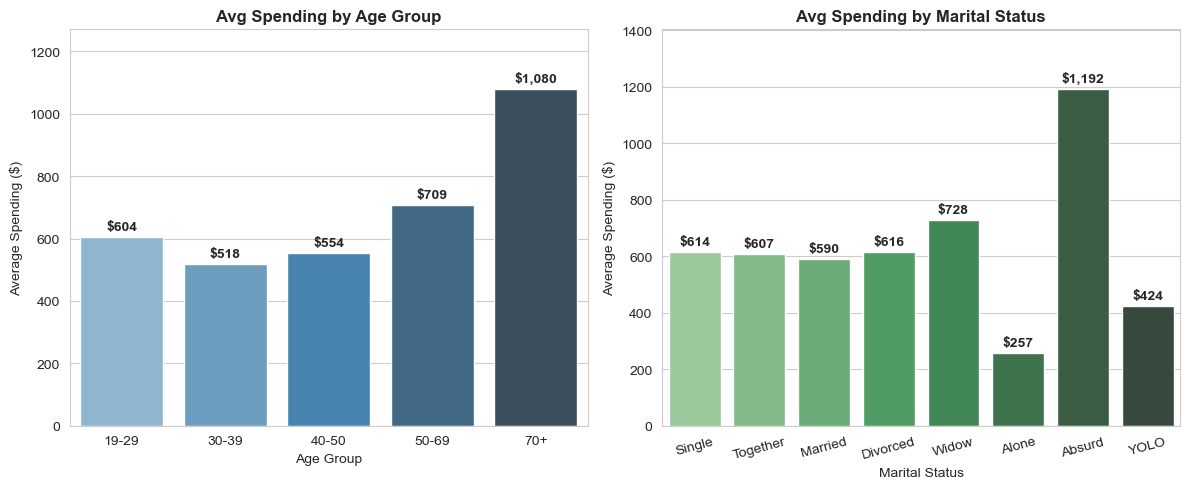

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x="age_group", y="total_spending", data=df, ax=axes[0], palette="Blues_d", errorbar=None)
axes[0].set_title("Avg Spending by Age Group", fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Average Spending ($)")
for p in axes[0].patches:
    h = p.get_height()
    axes[0].annotate(f"${h:,.0f}", (p.get_x() + p.get_width() / 2., h), ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontweight="bold")

sns.barplot(x="Marital_Status", y="total_spending", data=df, ax=axes[1], palette="Greens_d", errorbar=None)
axes[1].set_title("Avg Spending by Marital Status", fontweight="bold")
axes[1].set_xlabel("Marital Status")
axes[1].set_ylabel("Average Spending ($)")
axes[1].tick_params(axis="x", rotation=15)
for p in axes[1].patches:
    h = p.get_height()
    axes[1].annotate(f"${h:,.0f}", (p.get_x() + p.get_width() / 2., h), ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontweight="bold")

for ax in axes:
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

plt.tight_layout()
plt.show()

C:\Users\Windows\AppData\Local\Temp\ipykernel_22468\2194740543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["Accepted_Any_Campaign"].value_counts().index, y=df["Accepted_Any_Campaign"].value_counts().values, ax=axes[0], palette=["#C44E52", "#55A868"])
C:\Users\Windows\AppData\Local\Temp\ipykernel_22468\2194740543.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No (0)", "Yes (1)"])
C:\Users\Windows\AppData\Local\Temp\ipykernel_22468\2194740543.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accepted_Any_Campaign", y="total_spending", data=df, ax=axes[1], pale

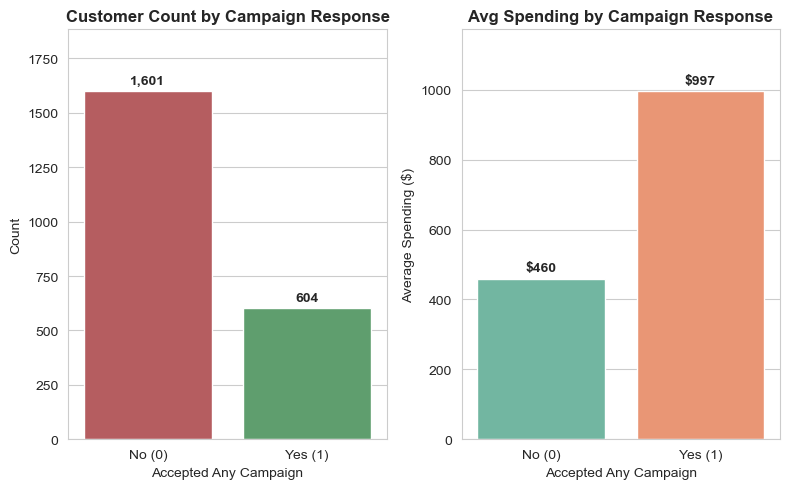

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

sns.barplot(x=df["Accepted_Any_Campaign"].value_counts().index, y=df["Accepted_Any_Campaign"].value_counts().values, ax=axes[0], palette=["#C44E52", "#55A868"])
axes[0].set_title("Customer Count by Campaign Response", fontweight="bold")
axes[0].set_xticklabels(["No (0)", "Yes (1)"])
axes[0].set_xlabel("Accepted Any Campaign")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    h = p.get_height()
    axes[0].annotate(f"{int(h):,}", (p.get_x() + p.get_width() / 2., h), ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontweight="bold")

sns.barplot(x="Accepted_Any_Campaign", y="total_spending", data=df, ax=axes[1], palette="Set2", errorbar=None)
axes[1].set_title("Avg Spending by Campaign Response", fontweight="bold")
axes[1].set_xticklabels(["No (0)", "Yes (1)"])
axes[1].set_xlabel("Accepted Any Campaign")
axes[1].set_ylabel("Average Spending ($)")
for p in axes[1].patches:
    h = p.get_height()
    axes[1].annotate(f"${h:,.0f}", (p.get_x() + p.get_width() / 2., h), ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontweight="bold")

for ax in axes:
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

plt.tight_layout()
plt.show()

C:\Users\Windows\AppData\Local\Temp\ipykernel_22468\1354595321.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_product_shares.values, y=mean_product_shares.index, ax=axes[0], palette="Purples_r")
C:\Users\Windows\AppData\Local\Temp\ipykernel_22468\1354595321.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_channel_shares.values, y=mean_channel_shares.index, ax=axes[1], palette="Oranges_r")


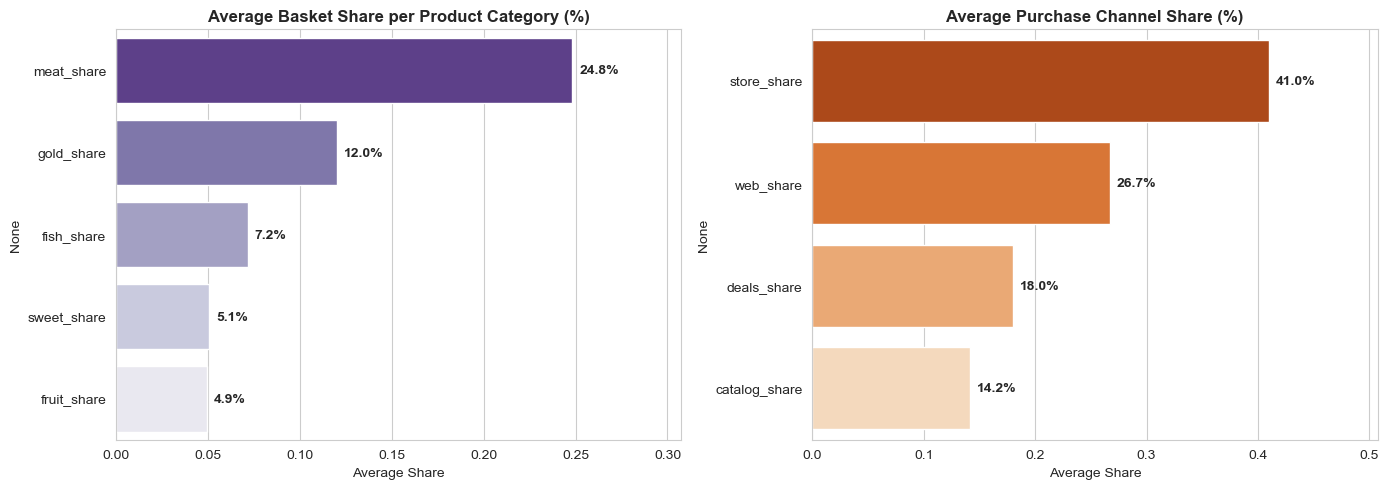

In [14]:
share_products = [col for col in ["meat_share", "fruit_share", "fish_share", "sweet_share", "gold_share"] if col in df.columns]
share_channels = [col for col in ["web_share", "catalog_share", "store_share", "deals_share"] if col in df.columns]

if share_products and share_channels:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    mean_product_shares = df[share_products].mean().sort_values(ascending=False)
    sns.barplot(x=mean_product_shares.values, y=mean_product_shares.index, ax=axes[0], palette="Purples_r")
    axes[0].set_title("Average Basket Share per Product Category (%)", fontweight="bold")
    axes[0].set_xlabel("Average Share")
    for p in axes[0].patches:
        w = p.get_width()
        axes[0].annotate(f"{w*100:.1f}%", (w, p.get_y() + p.get_height() / 2.), ha="left", va="center", xytext=(5, 0), textcoords="offset points", fontweight="bold")

    mean_channel_shares = df[share_channels].mean().sort_values(ascending=False)
    sns.barplot(x=mean_channel_shares.values, y=mean_channel_shares.index, ax=axes[1], palette="Oranges_r")
    axes[1].set_title("Average Purchase Channel Share (%)", fontweight="bold")
    axes[1].set_xlabel("Average Share")
    for p in axes[1].patches:
        w = p.get_width()
        axes[1].annotate(f"{w*100:.1f}%", (w, p.get_y() + p.get_height() / 2.), ha="left", va="center", xytext=(5, 0), textcoords="offset points", fontweight="bold")

    for ax in axes:
        ax.set_xlim(0, ax.get_xlim()[1] * 1.18)

    plt.tight_layout()
    plt.show()

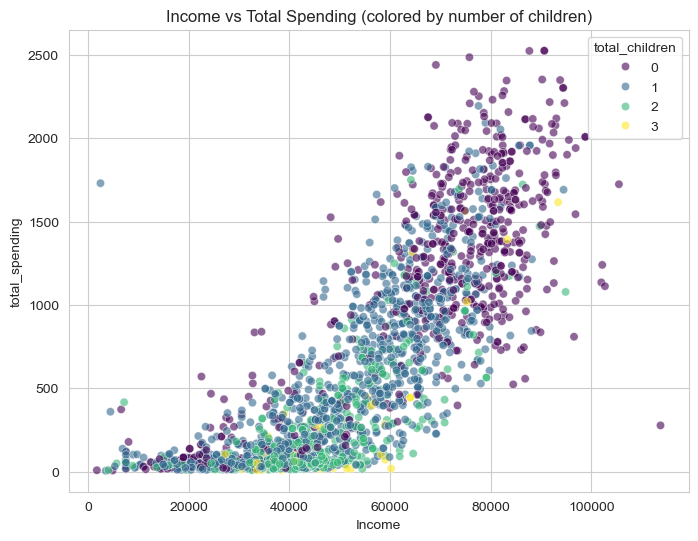

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Income", y="total_spending", hue="total_children", palette="viridis", alpha=0.6)
plt.title("Income vs Total Spending (colored by number of children)")
plt.show()

## Dropping Redundant Columns

The raw columns that were used to build the aggregate / share features are now redundant, along with a few irrelevant or target-like columns. Three malformed `Marital_Status` categories (`Absurd`, `YOLO`, `Alone`) are also filtered out.

In [16]:
cols_to_drop = [
    "age_group",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5",
    "Response", "Accepted_Any_Campaign", "Total_Accepted_Cmp",
    "Teenhome", "Kidhome", "Dt_Customer", "Year_Birth",
]

df = df.drop(columns=cols_to_drop)
df = df[~df["Marital_Status"].isin(["Absurd", "YOLO", "Alone"])].copy()

print(df.columns.tolist())
print("Shape:", df.shape)

['Education', 'Marital_Status', 'Income', 'Recency', 'NumDealsPurchases', 'NumWebVisitsMonth', 'Complain', 'age', 'total_children', 'total_spending', 'total_purchases', 'meat_share', 'fruit_share', 'fish_share', 'sweet_share', 'gold_share', 'deals_share', 'web_share', 'catalog_share', 'store_share', 'Customer_Days']
Shape: (2198, 21)


## Correlation Matrix

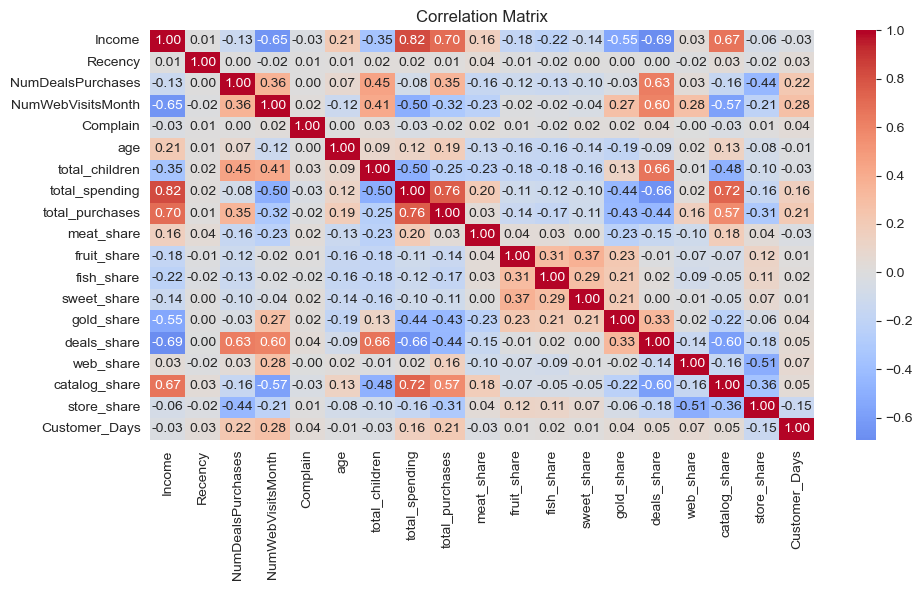

In [17]:
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## Save Feature-Engineered Dataset

In [18]:
df.to_csv("../data/processed/03_features.csv", index=False)
print("Saved:", df.shape)

Saved: (2198, 21)
